In [8]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sbi.analysis import pairplot
import pickle
import scipy
import yaml
import os
from sbc.sbc_tools import plot_sbc_all
from examples.gipps import plot_all

path_to_repo = "/Users/Lieve/Documents/Masters Project/SBC-SBI"
results_path = path_to_repo + "/results/real_examples/gipps_7d/nle_mcmc"
trajectories_path = path_to_repo + "/results/real_examples/gipps_7d/trajectories"

In [9]:
# We assume the following variables are fixed globally:
tau = 0.5
N = 100  # Number of tau-sized time steps to simulate
T = tau * N  # Total time simulated
psi = 1.05
ll = 7.5 # Length of leader car

# True follower parameters
af = 1.797
bf = -3.566
Vf = 28
xf0 = -22.521
vf0 = 10.148
mu = 0.8
sigmasquared = 0.25

# Define true parameter vector
true_theta = torch.tensor([af, bf, Vf, xf0, vf0, mu, sigmasquared])

# True leader parameters (all of these apart from bl are only needed for simulating leader trajectory).
# Note that these were not given in the paper
al = 2
bl = -4
Vl = 30
xl0 = 0
vl0 = 10
p_accel = 0.2
p_brake = 0.2

In [10]:
# Select leader trajectory ID
leader_trajectory_ID = 0

leader_trajectory_name = f"leader_trajectory{leader_trajectory_ID}"
path_to_leader_trajectory = trajectories_path + "/" + leader_trajectory_name + ".npz"
path_to_leader_trajectory_config = trajectories_path + "/" + leader_trajectory_name + ".yaml"

# Retrieve xl, vl
leader_trajectory = np.load(path_to_leader_trajectory)
xl = leader_trajectory["xl"]
vl = leader_trajectory["vl"]

# Retrieve leader trajectory config
with open(path_to_leader_trajectory_config, "r") as f:
    leader_trajectory_config = yaml.safe_load(f) # Dictionary containing all information about xl, vl

In [11]:
# Select observed follower trajectory ID
follower_trajectory_ID = 0

follower_trajectory_name = f"follower_trajectory{follower_trajectory_ID}_leader_trajectory{leader_trajectory_ID}"
path_to_follower_trajectory = trajectories_path + "/" + follower_trajectory_name + ".npz"
path_to_follower_trajectory_config = trajectories_path + "/" + follower_trajectory_name + ".yaml"

# Retrieve xf_obs, vf_obs
follower_trajectory = np.load(path_to_follower_trajectory)
xf_obs = follower_trajectory["xf"]
vf_obs = follower_trajectory["vf"]

# Retrieve follower trajectory config
with open(path_to_follower_trajectory_config, "r") as f:
    follower_trajectory_config = yaml.safe_load(f) # Dictionary containing all information about xf, vf

In [12]:
# Define prior hyperparameters
# This is the exact prior used in the paper
aL, aU = 0.5, 3.5
bL, bU = -6, -1
VL, VU = 15, 35
xf0L, xf0U = -60, -10
vf0L, vf0U = 5, 25
prior_mean_mu, prior_variance_mu = 0., 9.
prior_alpha_sigmasquared, prior_beta_sigmasquared = 1., 3.

# Define prior supports only for the 5 uniform parameters
prior_supports = [(aL, aU), (bL, bU), (VL, VU), (xf0L, xf0U), (vf0L, vf0U)]

SEQUENTIAL POSTERIOR TBC....

SBC

In [13]:
sequential_sbc_ID = 0

path_to_sequential_sbc = results_path + f"/sequential_sbc{sequential_sbc_ID}_leader_trajectory{leader_trajectory_ID}" + ".npz"
path_to_sequential_sbc_config = results_path + f"/sequential_sbc{sequential_sbc_ID}_leader_trajectory{leader_trajectory_ID}" + ".yaml"

# Retrieve sequential sbc ranks
sequential_ranks = np.load(path_to_sequential_sbc)

# Retrieve sequential sbc config
with open(path_to_sequential_sbc_config, "r") as f:
    sequential_sbc_config = yaml.safe_load(f) # Dictionary containing all information about this sbc run.

# Get N_iter and N_samp from config file
N_iter = sequential_sbc_config["sbc_config"]["N_iter"]
N_samp = sequential_sbc_config["sbc_config"]["N_samp"]

# Compute number of failed SNPE-C runs
num_failed_runs = sum(np.isnan(sequential_ranks["projection0"]))
print(f"{num_failed_runs} out of {N_iter} failed SNPE-C runs.")

sequential_sbc_config

0 out of 191 failed SNPE-C runs.


{'leader_trajectory_config': {'N': 100,
  'Vl': 30.0,
  'al': 2.0,
  'bl': -4.0,
  'p_accel': 0.2,
  'p_brake': 0.2,
  'tau': 0.5,
  'vl0': 10.0,
  'xl0': 0.0},
 'prior_config': {'VL': 15.0,
  'VU': 35.0,
  'aL': 0.5,
  'aU': 3.5,
  'bL': -6.0,
  'bU': -1.0,
  'prior_alpha_sigmasquared': 1.0,
  'prior_beta_sigmasquared': 3.0,
  'prior_mean_mu': 0.0,
  'prior_variance_mu': 9.0,
  'vf0L': 5.0,
  'vf0U': 25.0,
  'xf0L': -60.0,
  'xf0U': -10.0},
 'sbc_config': {'N': 100,
  'N_iter': 191,
  'N_samp': 5000,
  'bl': -4.0,
  'density_estimator': 'maf',
  'leader_trajectory_ID': 0,
  'll': 7.5,
  'mcmc_method': 'slice_np_vectorized',
  'num_sequential_rounds': 4,
  'num_simulations_per_round': 5000,
  'psi': 1.05,
  'sbc_times': [1490.3600321030244,
   1455.5176855321042,
   1556.4658649968915,
   1306.5013193460181,
   1456.851176890079,
   1602.6591645600274,
   1570.5717134661973,
   1434.2735883137211,
   1311.0724817407317,
   1371.8038372560404,
   1458.9798927819356,
   1237.963290823157

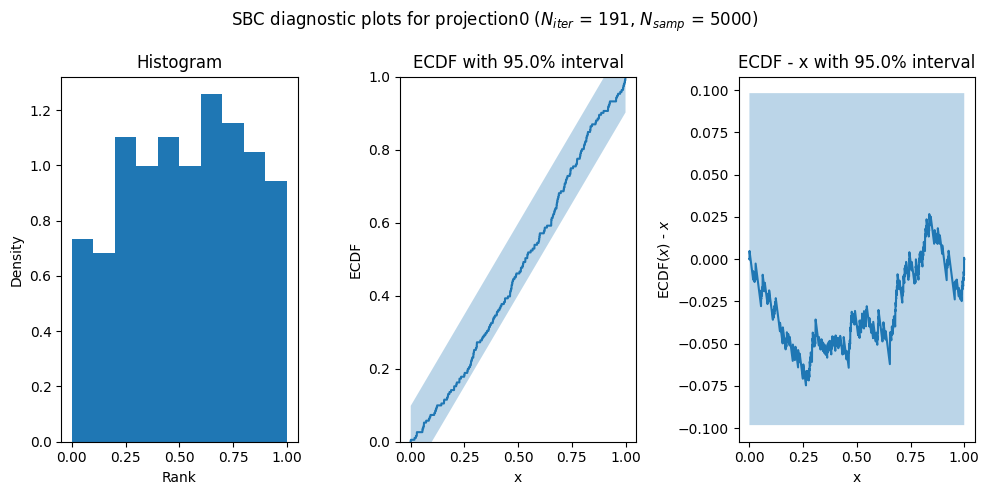

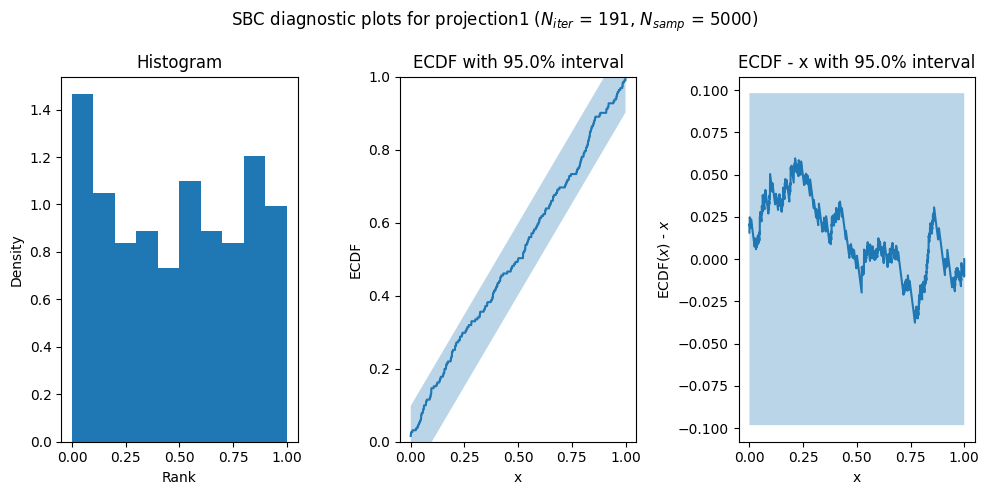

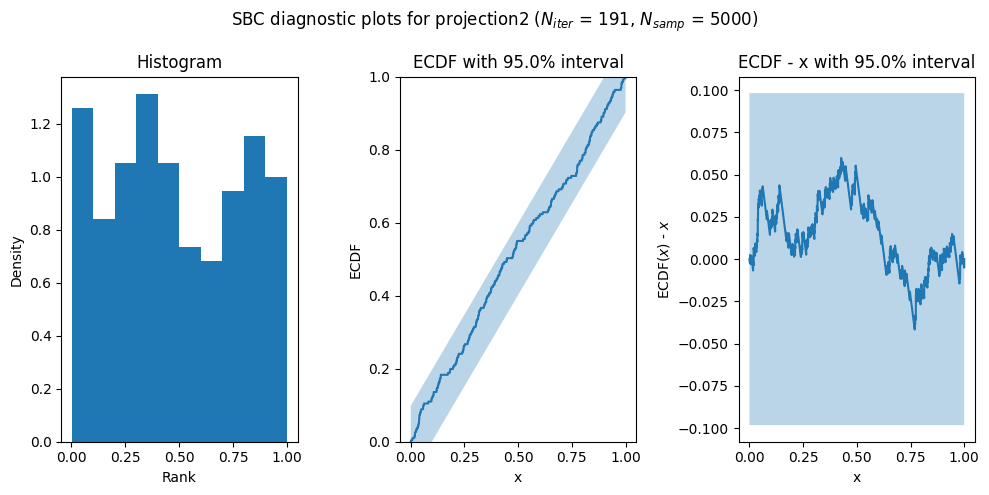

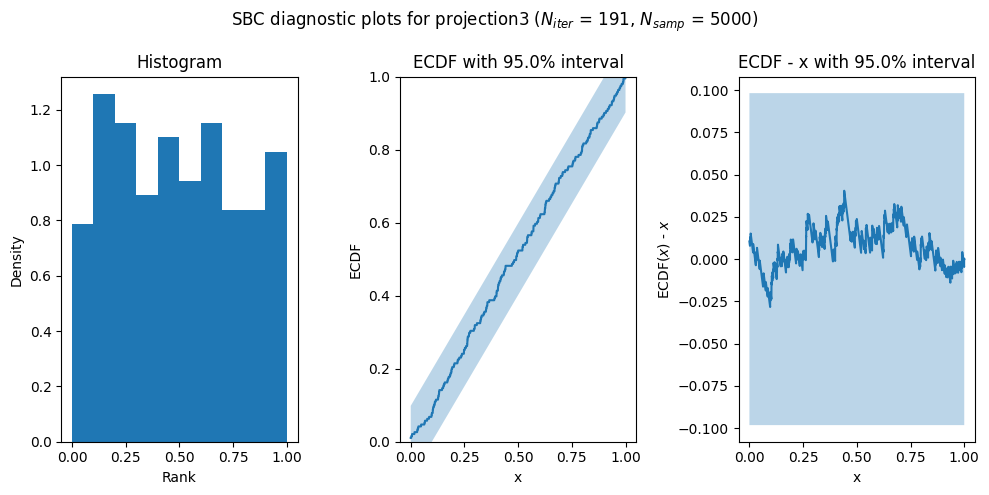

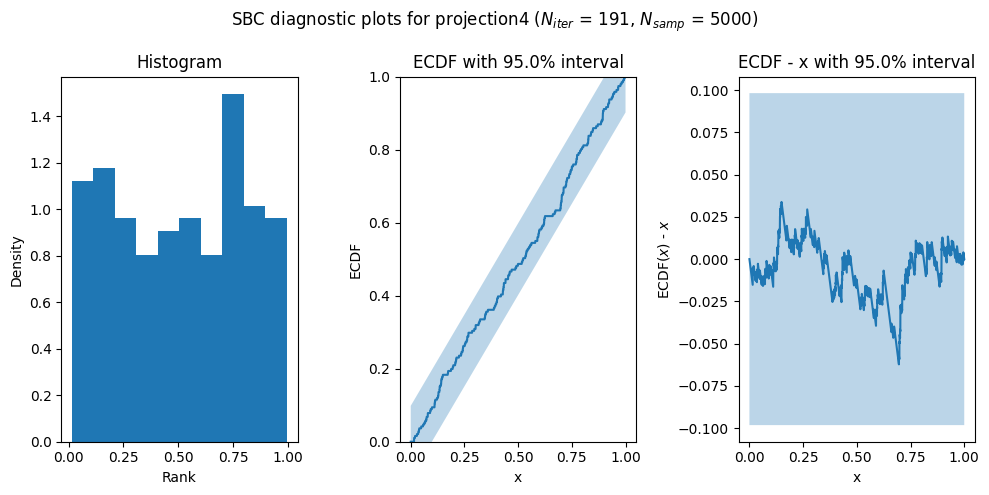

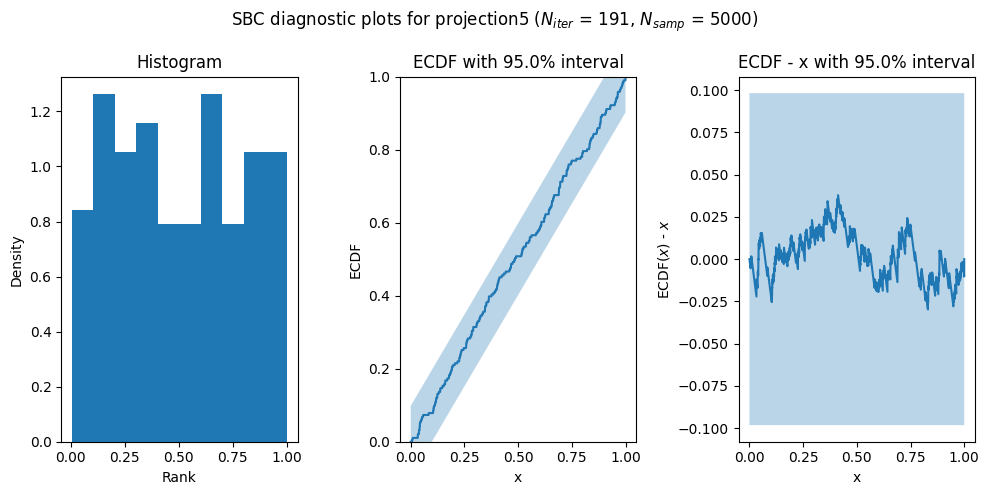

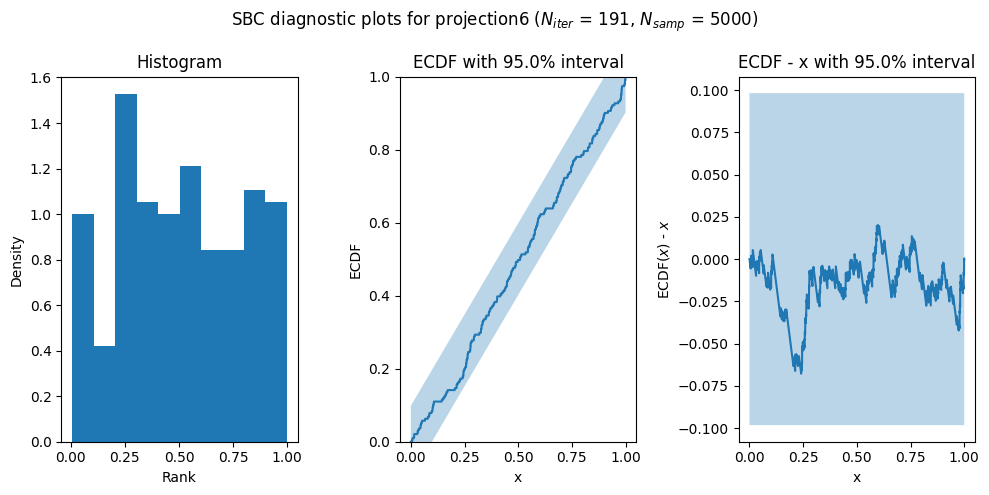

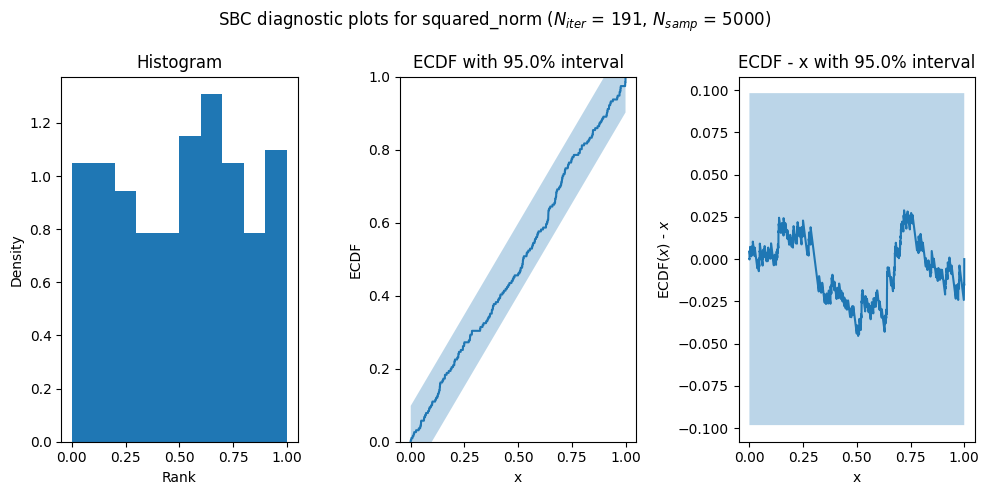

In [14]:
for test_function_name, ranks in sequential_ranks.items():
    title=fr"SBC diagnostic plots for {test_function_name}" + r" ($N_{iter}$ = " + f"{N_iter}, " + r"$N_{samp}$ = " + f"{N_samp})"
    plot_sbc_all(ranks=ranks, N_samp=N_samp, title=title)